In [12]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from dask.distributed import Client
c = Client()
c

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 6
Total threads: 36,Total memory: 160.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36834,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40209,Total threads: 6
Dashboard: /proxy/42482/status,Memory: 26.67 GiB
Nanny: tcp://127.0.0.1:38264,


In [16]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"abyssal_sigma2_depths.zarr"

ds = xr.open_mfdataset(savename).sel(year = slice(None, 2099))

ds_abyssal_depth = ds.sel(sigma2 = 37.1, method = "nearest").depth
# ds_abyssal_depth = ds_abyssal_depth.where(ds_abyssal_depth < -200)

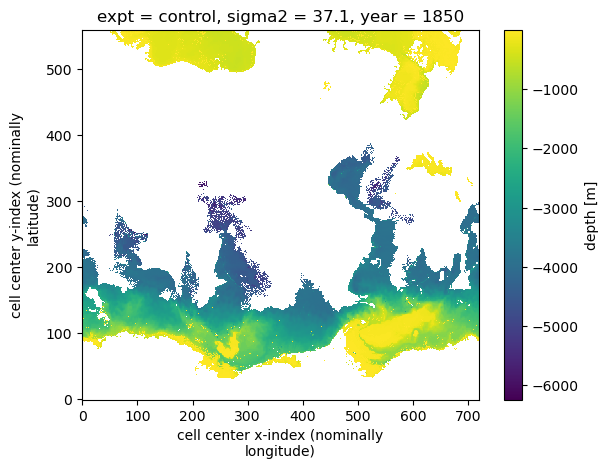

In [17]:
ds_abyssal_depth.isel(expt = 0, year = 0).plot()

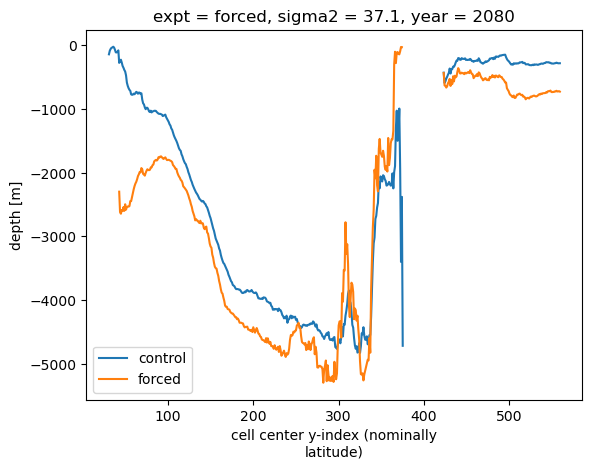

In [18]:
ds_abyssal_depth.isel(year = -20).sel(expt = "control").mean("xh").plot(label = "control")
ds_abyssal_depth.isel(year = -20).sel(expt = "forced").mean("xh").plot(label = "forced")
plt.legend()

In [19]:
def find_constistent_divergence(ts_ds, window_size=25, min_consistent_years=25):
    """
    Find when a forced run diverges from a control run using a window-local sign-consistency test.

    The function forms ts_diff = forced - control, then for each centered `window_size`-year window
    computes the 2.5th and 97.5th percentiles of ts_diff within the window. A year is flagged as
    diverged if that window’s central 95% interval excludes zero (lower > 0 or upper < 0). It then
    returns the first year after which divergence holds through the end of the record, computed
    pointwise over any additional dimensions. If the end-persistent divergence segment is shorter
    than `min_consistent_years`, the start year is set to NaN.

    Parameters
    ----------
    ts_ds : xarray.DataArray or xarray.Dataset
        Must support .sel(expt="forced"/"control") and have a ``year`` dimension.

    window_size : int, default 25
        Rolling window length in years (centered; full windows required).

    min_consistent_years : int, default 1
        Minimum length (in years/samples) required for the end-persistent divergence segment.

    Returns
    -------
    divergence_start_year : xarray.DataArray
        Start year of end-persistent divergence (NaN where divergence does not persist to the end
        or where the end-persistent segment is shorter than `min_consistent_years`).
    """
    ts_diff = ts_ds.sel(expt="forced") - ts_ds.sel(expt="control")

    win = (
        ts_diff.rolling(year=window_size, center=True, min_periods=window_size)
              .construct("window")
    )

    ts_lower = win.quantile(0.025, dim="window", skipna=True)
    ts_upper = win.quantile(0.975, dim="window", skipna=True)

    when_diverged = (ts_lower > 0) | (ts_upper < 0)
    flag = when_diverged.fillna(False).astype(bool)

    diverged_to_end = (
        flag.isel(year=slice(None, None, -1))
            .astype("int8")
            .cumprod("year")
            .astype(bool)
            .isel(year=slice(None, None, -1))
    )

    divergence_start_year = diverged_to_end.idxmax("year").where(diverged_to_end.any("year"))

    seglen = diverged_to_end.sum("year")
    divergence_start_year = divergence_start_year.where(seglen >= min_consistent_years)

    return divergence_start_year, seglen

In [20]:
window_size = 25; 
min_consistent_years = 25
divergence_start_year, seglen = find_constistent_divergence(ds_abyssal_depth, 
                                                            window_size = window_size,
                                                           min_consistent_years = min_consistent_years)
divergence_start_year = divergence_start_year.compute()

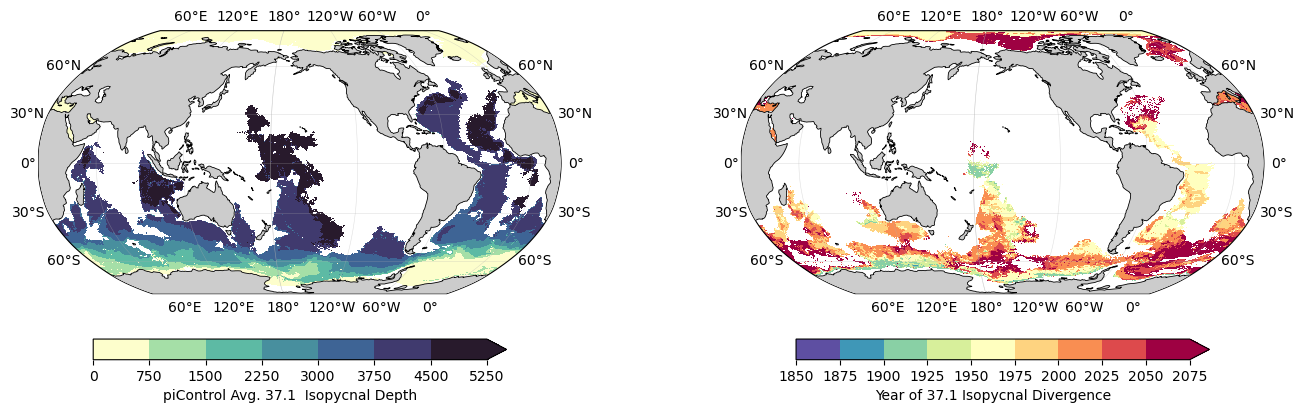

In [21]:
def make_bounds(da, step, vmin = None, vmax = None):
    if vmin is None:
        vmin = float(da.min(skipna=True))
    if vmax is None:
        vmax = float(da.max(skipna=True))
    return np.arange(np.floor(vmin/step)*step, np.ceil(vmax/step)*step + step, step)
    

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson(central_longitude = -160)

sigma2_value = np.round(ds_abyssal_depth.sigma2.values, decimals = 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj_map}, constrained_layout=True)

ax = axes[0]; 
background_depth = -ds_abyssal_depth.mean("year").sel(expt = "control").compute()
cmap = cmo.deep
step = 750
bounds = make_bounds(background_depth, step, vmax = background_depth.quantile(0.975))
cmap = plt.get_cmap(cmap, len(bounds) - 1)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=False)

pc = ax.pcolormesh(
background_depth["geolon"], background_depth["geolat"], background_depth,
transform=proj_data, cmap=cmap, norm=norm
)
cb0 = fig.colorbar(pc, ax=ax, ticks=bounds, shrink=0.6, pad=0.08, extend = "max", orientation = "horizontal")
cb0.set_label(f"piControl Avg. {sigma2_value}  Isopycnal Depth")

ax = axes[1]
cmap = "Spectral_r"
step = window_size
bounds = make_bounds(divergence_start_year, step)
cmap = plt.get_cmap(cmap, len(bounds) - 1)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=False)

pc = ax.pcolormesh(
divergence_start_year["geolon"], divergence_start_year["geolat"], divergence_start_year,
transform=proj_data, cmap=cmap, norm=norm
)

cb0 = fig.colorbar(pc, ax=ax, ticks=bounds, shrink=0.6, pad=0.08, extend = "max", orientation = "horizontal")
cb0.set_label(f"Year of {sigma2_value} Isopycnal Divergence from Control")

for ax in axes:
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=3)
    ax.coastlines(linewidth=0.6, zorder=4)
    ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)